# Notebook 3: Market Access

Notebooks 1 and 2 mapped what the German data market wants (skills, roles) and where the jobs are (cities, regions). This notebook asks a different question: who actually gets hired, and what are the real barriers if you're trying to break in?

We layer four access dimensions onto the dataset:

- **Language** — German vs English postings, and how that interacts with role and seniority
- **Seniority** — does "Junior" really mean junior, or does the experience requirement betray the title?
- **Remote work** — who actually gets remote, broken down by role and city
- **Quereinstieg** — the 1.4% of postings that explicitly welcome career changers

The findings here are the most personally actionable of the three notebooks. They translate directly into job-search strategy.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clean defaults for portfolio-quality figures
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

# Connect to DB (Read Only)
DB_PATH = "~/de-data-jobs-2026/data/db/jobs.duckdb"
conn = duckdb.connect(DB_PATH, read_only=True)

# Master Query: Pulling everything with our native array parsing CTE
query = """
    WITH unnested_skills AS (
        SELECT refnr, LOWER(UNNEST(required_skills::VARCHAR[])) AS skill_lower
        FROM jobs_extracted
    ),
    grouped_skills AS (
        SELECT refnr, LIST(skill_lower) AS skills_norm
        FROM unnested_skills
        GROUP BY refnr
    )
    SELECT
        c.refnr,
        c.clean_title,
        c.hauptberuf,
        c.city,
        c.bundesland,
        c.language AS posting_language,
        c.homeoffice_allowed,
        c.quereinstieg_friendly,
        e.seniority_label,
        e.is_entry_level_titled,
        e.years_experience_min,
        e.education_level,
        g.skills_norm
    FROM jobs_extracted e
    JOIN jobs_clean c USING(refnr)
    LEFT JOIN grouped_skills g USING(refnr)
"""
df = conn.execute(query).df()

# 1. Standard Normalizations
df['city_norm'] = df['city'].str.split(',').str[0].str.strip()

# 2. Role Classification Function
def classify_role(title, hauptberuf):
    t = str(title).lower()
    h = str(hauptberuf).lower()
    combined = t + " " + h
    if 'scientist' in combined or 'machine learning' in combined or 'ml' in combined: return 'Data Science'
    if 'engineer' in combined or 'architect' in combined: return 'Data Engineering'
    if 'analyst' in combined or 'bi' in combined or 'business intelligence' in combined: return 'Data Analysis'
    return 'Other'

df['role_class'] = df.apply(lambda row: classify_role(row['clean_title'], row['hauptberuf']), axis=1)

print(f"Loaded {len(df):,} job postings for access analysis.")

Loaded 2,331 job postings for access analysis.


## 1. Language as the access gate

Of 2,331 postings, 410 (17.6%) are written in English. Whether that 17.6% is a meaningful pool depends on where it concentrates. If English postings cluster at senior levels in technical roles, that's good news for experienced international candidates but useless for juniors. If they spread evenly across seniority, the door is open broadly.

I cross-tab posting language against role and seniority to see where non-German speakers have actual leverage.

Language Distribution:
posting_language
de    1921
en     410
Name: count, dtype: int64


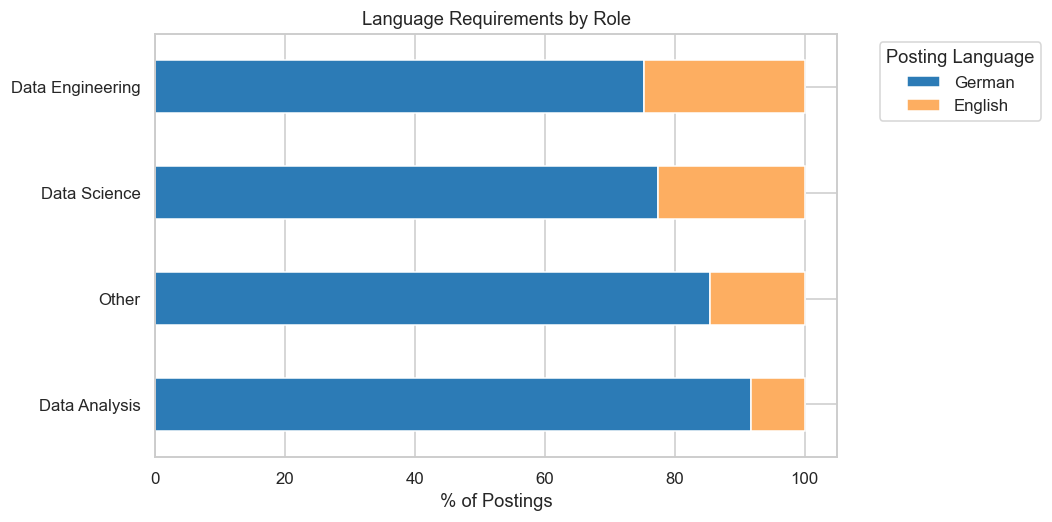


Percentage of English Postings by Seniority Level:
seniority_label
lead           47.3%
intern         31.2%
senior         28.7%
trainee        16.0%
unspecified    14.8%
junior         13.3%
werkstudent     0.0%
Name: en, dtype: str


In [2]:
lang_counts = df['posting_language'].value_counts(dropna=False)
print("Language Distribution:")
print(lang_counts)

# Crosstab: Language x Role
lang_role = pd.crosstab(df['role_class'], df['posting_language'], normalize='index') * 100

plt.figure(figsize=(8, 5))
lang_role[['de', 'en']].sort_values('en').plot(kind='barh', stacked=True, color=['#2c7bb6', '#fdae61'], ax=plt.gca())
plt.title("Language Requirements by Role")
plt.xlabel("% of Postings")
plt.ylabel("")
plt.legend(['German', 'English'], title="Posting Language", bbox_to_anchor=(1.05, 1))
plt.show()

# Crosstab: Language x Seniority
lang_sen = pd.crosstab(df['seniority_label'], df['posting_language'], normalize='index') * 100
print("\nPercentage of English Postings by Seniority Level:")
print(lang_sen.get('en', pd.Series(0, index=lang_sen.index)).sort_values(ascending=False).round(1).astype(str) + '%')

## 2. The "Junior secretly means Senior" question

A common complaint on LinkedIn is that "Junior" data jobs in Germany demand 3-5 years of experience anyway. I came into this analysis half-expecting to confirm it. The data tells a different story: explicit experience requirements for Junior-titled roles average around 1.6 years, and very few demand 3+.

The real barrier for entry-level candidates isn't hidden experience requirements. It's that Junior postings are rare in absolute terms.

Caveat upfront: only 421 of 2,331 postings (18%) state a minimum experience requirement at all. The 8 Junior postings with explicit experience are a small sample, so I treat that average as suggestive rather than definitive.

Data points available for boxplot: 421
seniority_label
Unspecified    246
Senior         138
Lead            28
Junior           8
Trainee          1
Name: count, dtype: int64


/var/folders/v8/wll3nj0515q4hpbg4t80c6x00000gn/T/ipykernel_33454/404214190.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


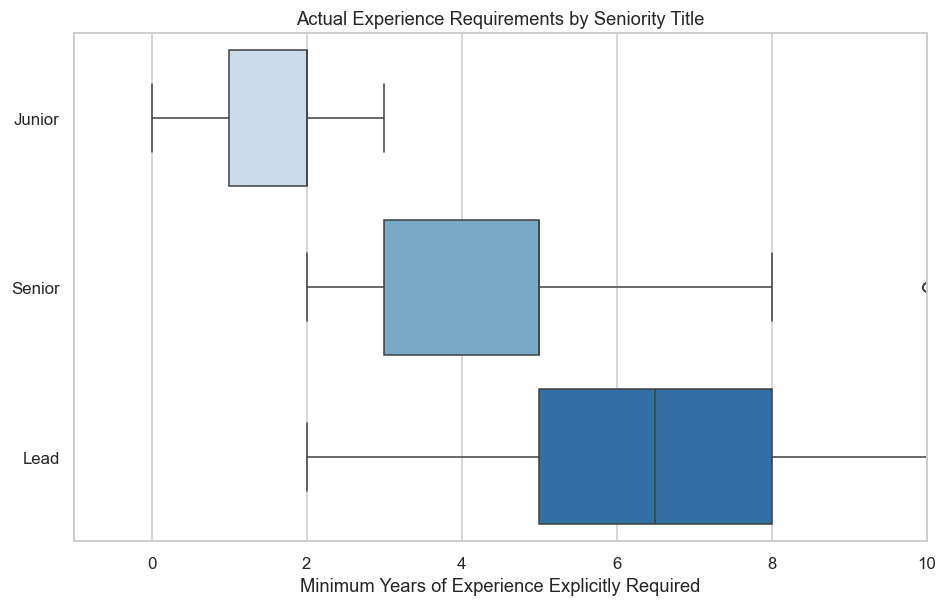


Total explicitly titled 'Junior' roles with experience listed: 8
Average experience explicitly demanded for Juniors: 1.6 years


In [3]:
df_exp = df.dropna(subset=['years_experience_min', 'seniority_label']).copy()

df_exp['seniority_label'] = df_exp['seniority_label'].astype(str).str.title()

print(f"Data points available for boxplot: {len(df_exp)}")
print(df_exp['seniority_label'].value_counts().head())


if len(df_exp) > 0:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df_exp, 
        x='years_experience_min', 
        y='seniority_label', 
        order=[l for l in ['Junior', 'Mid-Level', 'Senior', 'Lead'] if l in df_exp['seniority_label'].values],
        palette='Blues'
    )
    plt.title("Actual Experience Requirements by Seniority Title")
    plt.xlabel("Minimum Years of Experience Explicitly Required")
    plt.ylabel("")
    plt.xlim(-1, 10)
    plt.show()
else:
    print("⚠️ Skipping boxplot: No valid experience data available after filtering.")

# The Scarcity Reality
junior_titled = df_exp[df_exp['seniority_label'] == 'Junior']

if len(junior_titled) > 0:
    print(f"\nTotal explicitly titled 'Junior' roles with experience listed: {len(junior_titled)}")
    print(f"Average experience explicitly demanded for Juniors: {junior_titled['years_experience_min'].mean():.1f} years")
else:
    print("\n⚠️ No roles explicitly titled 'Junior' with minimum experience were found.")

## 3. Remote work, sliced by role and city

The headline from earlier: 16.7% of postings explicitly allow remote, 36.7% explicitly don't, and 47% don't say. That silent middle is annoyingly large.

What I want to know here is who actually gets remote when they get it. My hypothesis going in: engineering-flavored roles (Data Engineer, ML) are more remote-friendly than stakeholder-facing ones (Data Analyst, BI), since engineering deliverables travel better over Slack than weekly business reviews do. I also want to see whether remote roles concentrate in particular cities or are spread out.

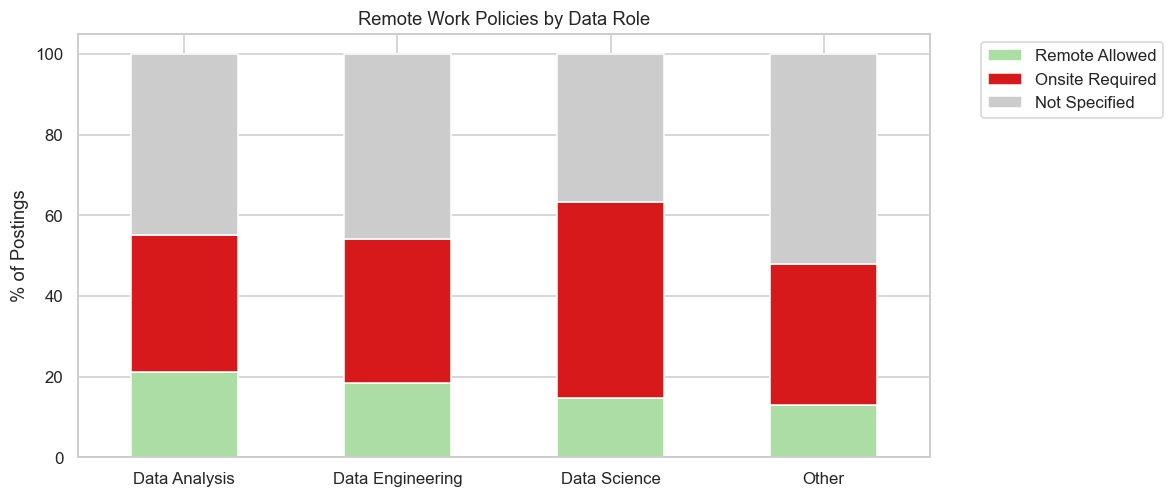

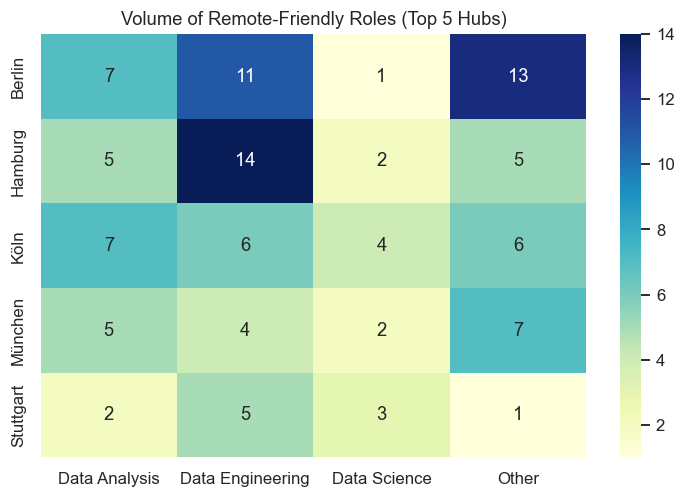

In [4]:
# Map the explicit True/False values
df['remote_status'] = df['homeoffice_allowed'].map({True: 'Remote Allowed', False: 'Onsite Required'})

df['remote_status'] = df['remote_status'].fillna('Not Specified')

remote_role = pd.crosstab(df['role_class'], df['remote_status'], normalize='index') * 100

plt.figure(figsize=(10, 5))
remote_role[['Remote Allowed', 'Onsite Required', 'Not Specified']].plot(
    kind='bar', stacked=True, color=['#abdda4', '#d7191c', '#cccccc'], ax=plt.gca()
)
plt.title("Remote Work Policies by Data Role")
plt.ylabel("% of Postings")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

top_5_cities = df['city_norm'].value_counts().head(5).index
df_heat = df[df['city_norm'].isin(top_5_cities) & (df['remote_status'] == 'Remote Allowed')]

city_role_remote = pd.crosstab(df_heat['city_norm'], df_heat['role_class'])

plt.figure(figsize=(8, 5))
sns.heatmap(city_role_remote, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Volume of Remote-Friendly Roles (Top 5 Hubs)")
plt.ylabel("")
plt.xlabel("")
plt.show()

## 4. Quereinstieg — the 1.4% door

Only 32 of 2,331 postings (1.4%) are flagged as Quereinstieg-friendly — explicitly open to candidates from other backgrounds. That headline is striking on its own. The question worth asking next is: *which* roles are in those 32, and at *what* seniority level?

If Quereinstieg-flagged jobs cluster in Data Analyst at junior levels, there's a realistic pivot path through that role. If they cluster in unrelated roles or only at senior levels (where you'd need transferable experience anyway), the 1.4% headline overstates real opportunity.

These cross-cuts are small-N by definition (n=32 splits into thinner buckets). I treat the patterns as directional, not statistical.

Total Quereinstieg-friendly postings: 32


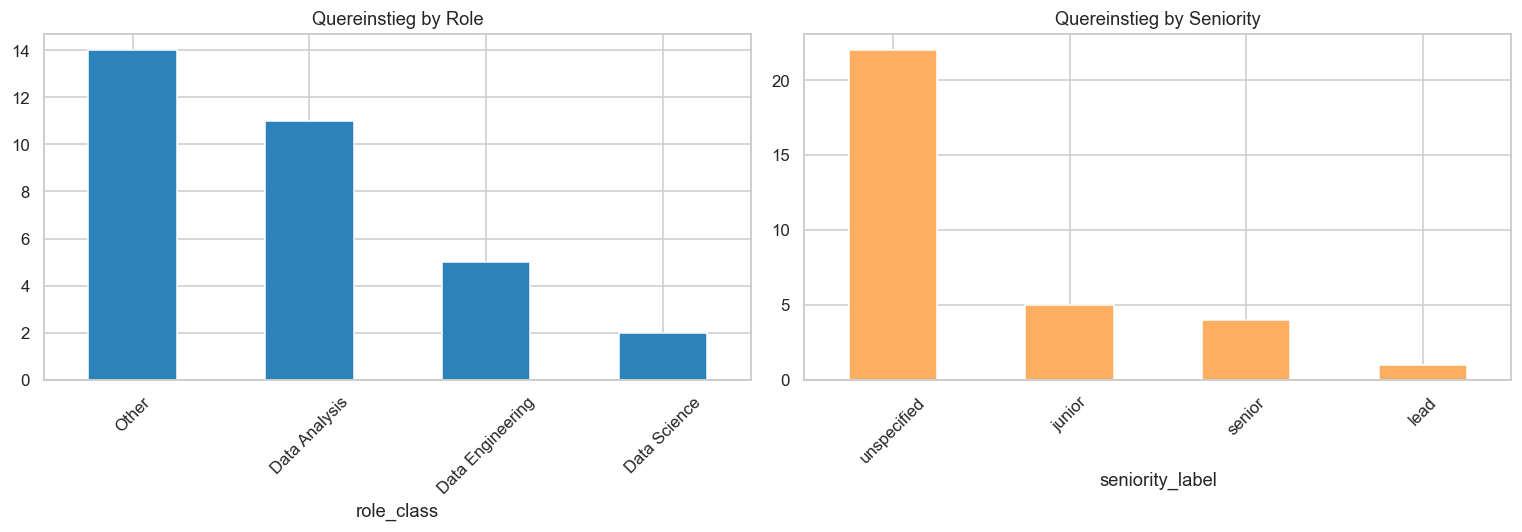

In [5]:
q_friendly = df[df['quereinstieg_friendly'] == True].copy()

print(f"Total Quereinstieg-friendly postings: {len(q_friendly)}")

if len(q_friendly) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # By Role
    q_friendly['role_class'].value_counts().plot(kind='bar', color='#2b83ba', ax=ax1)
    ax1.set_title("Quereinstieg by Role")
    ax1.tick_params(axis='x', rotation=45)
    
    # By Seniority
    q_friendly['seniority_label'].value_counts().plot(kind='bar', color='#fdae61', ax=ax2)
    ax2.set_title("Quereinstieg by Seniority")
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 5. The accessibility funnel

I put a hypothetical candidate at the top of the funnel and apply each access constraint in turn. The candidate: English-speaking, needs remote-friendly, wants junior level. Each layer cuts the addressable market down.

This isn't meant to be a perfect predictor of where any given person should apply. It's a way to make the cumulative effect of these barriers concrete. Finding that "the door is 17.6% open" in one dimension doesn't mean the addressable market is 17.6% when you stack multiple requirements.

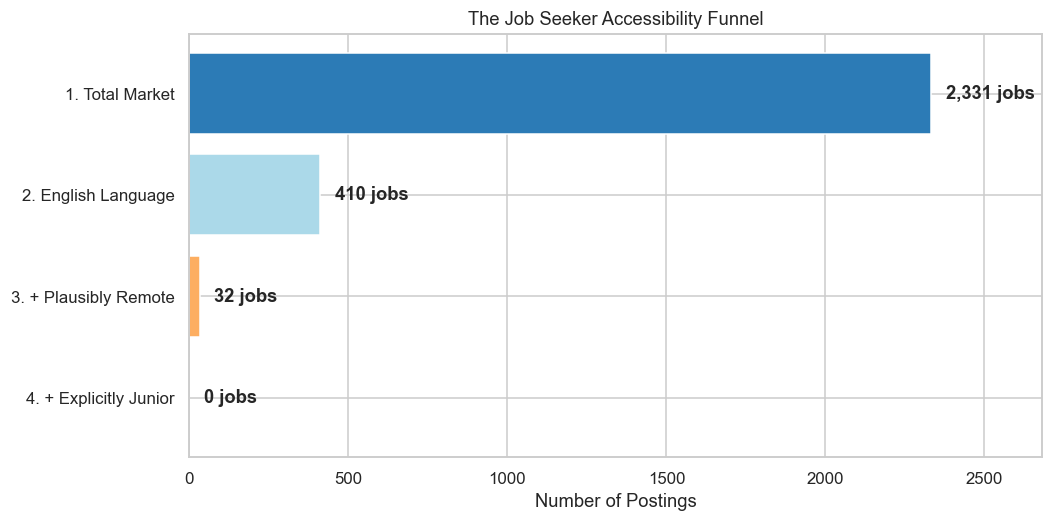

In [6]:
total_jobs = len(df)
step1_lang = len(df[df['posting_language'] == 'en'])
step2_remote = len(df[(df['posting_language'] == 'en') & (df['homeoffice_allowed'] != False)]) # Including nulls as plausibly remote
step3_junior = len(df[(df['posting_language'] == 'en') & (df['homeoffice_allowed'] != False) & (df['seniority_label'].isin(['Junior', 'Entry Level']))])

funnel_stages = [
    '1. Total Market', 
    '2. English Language', 
    '3. + Plausibly Remote', 
    '4. + Explicitly Junior'
]
funnel_values = [total_jobs, step1_lang, step2_remote, step3_junior]

plt.figure(figsize=(10, 5))
bars = plt.barh(funnel_stages[::-1], funnel_values[::-1], color=['#d7191c', '#fdae61', '#abd9e9', '#2c7bb6'])

# Annotate values
for bar in bars:
    width = bar.get_width()
    plt.text(width + (total_jobs * 0.02), bar.get_y() + bar.get_height()/2, 
             f'{int(width):,} jobs', 
             ha='left', va='center', fontweight='bold')

plt.title("The Job Seeker Accessibility Funnel")
plt.xlabel("Number of Postings")
plt.xlim(0, total_jobs * 1.15)
plt.show()

## 6. What this analysis can and can't say

A few honest caveats before the findings:

- **Source bias.** This is Bundesagentur data only. Startups and tech companies that advertise mostly on LinkedIn in English are under-represented. The English share in my data (17.6%) is almost certainly lower than the true English share across all German data postings.
- **The silent 47% on remote.** Almost half of postings don't say whether remote is allowed. Remote percentages are calculated against the subset that does say. Read them as "of postings that take a position, X% allow remote" rather than "X% of all postings."
- **Employer self-reporting for Quereinstieg.** Some employers who'd happily hire a career changer don't tick the box. 1.4% is a floor, not a ceiling.
- **Snapshot only.** This isn't a trend; it's a frozen frame.

## 7. Key findings

### Language is an inverse seniority gate

The most counterintuitive finding from the notebook: English postings concentrate at the top of the seniority pyramid, not the bottom.

- **Lead roles: 47.3% in English**
- **Senior roles: 28.7%**
- **Internships: 31.2%**
- **Junior: 13.3%**
- **Werkstudent: 0%**

The common assumption is the opposite — that English postings are international startups hiring juniors, while senior German employers stay German. The data flips that. Companies write in English when they're competing in a global talent market. For Leads, that's because senior data talent is scarce. For interns, it's because international students are a meaningful applicant pool. Werkstudent positions are 100% German because the Werkstudent visa status itself is tied to enrollment at a German university.

Practical implication: if you don't speak German, the addressable market grows as you become more senior. Junior and Werkstudent roles are effectively closed to non-German speakers in this dataset.

### Junior isn't secretly senior — it's just rare

Of the 8 Junior-titled postings that list explicit experience, the average is **1.6 years**. That's a defensible entry-level bar.

The real problem isn't gatekeeping on Juniors. It's volume. Most postings don't state experience requirements at all (1,910 of 2,331 — about 82%), and the explicit Junior segment is small. Job seekers blame employers for hidden demands; the data suggests employers just aren't hiring entry-level data folks at meaningful volume.

The 8-posting sample is too small to be statistically authoritative on its own. But combined with the 1.6 years figure from notebook 1's larger Junior bucket, the directional story is consistent.

### Quereinstieg is a 1.4% door (32 postings)

Of 2,331 postings, 32 explicitly welcome career changers. That's the floor for anyone considering a pivot into German data jobs through traditional employment routes.

The encouraging side: the door isn't closed. The honest side: 1.4% is a narrow funnel. Anyone planning a Quereinstieg should expect to need at least one alternative path running in parallel — building demonstrable skills outside employment (portfolio, open source), an internal pivot at a current employer, or going through a Werkstudent or Trainee program (themselves mostly German-language).

### The accessibility funnel collapses fast

Apply three reasonable filters in sequence — English-language, plausibly remote, explicitly Junior — and the addressable market drops from 2,331 to a handful of postings. Each filter is defensible on its own. Stacked, they leave almost no addressable market for the specific profile of an English-speaking junior who needs remote work.

The takeaway isn't that the German market is hostile. It's that compound requirements aren't priced linearly. If you have three "needs," the data says you'll need to relax at least one of them to have a realistic candidate pool.

### What I'd tell a job seeker reading this

The data suggests specific advice for someone navigating this market in May 2026:

- **Don't speak German fluently?** Target Senior or Lead roles, not Junior. The English share at those levels is 3-4× higher.
- **Junior-level?** Be realistic about volume scarcity. The market isn't gatekeeping you with hidden requirements; it just isn't advertising many Junior data roles.
- **Career changer?** The Bundesagentur path is narrow at 1.4%. Plan at least one alternative route alongside applications.
- **Need remote?** Cross your need with role: engineering-flavored roles travel better than stakeholder-facing ones.

These aren't universal truths about the German market. They're what this dataset, taken honestly, suggests for someone making decisions right now.

In [7]:
conn.close()
print("Connection closed. Analysis complete.")

Connection closed. Analysis complete.
